# data_transform_new

Notebook copy of `data_transform_new.py`.

## Shared Imports
Common imports and dependencies used across the notebook.

In [1]:
# Imports and shared dependencies

import os
import time
from collections import defaultdict
from typing import Optional, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


## Data Loading and Feature Engineering
Transforms raw step logs into model-ready features.

In [2]:
# Data loading and feature engineering

def load_and_transform(path: str) -> pd.DataFrame:
    """Load a stats.json file and compute derived fields."""
    df = pd.read_json(path, lines=True)
    df["source_file"] = path
    df["full_progress"] = (df["num_denoise_ran"] + 1) / df["output_length"]
    df["full_unmask_progress"] = df["num_unmasked_tokens"] / df["output_length"]
    df["block_progress"] = df["block"] / (df["output_length"] / df["block_size"])
    df["block_unmask_progress"] = df["block_num_unmasked_tokens"] / df["block_size"]
    final_denoise = df.groupby("id")["num_denoise_ran"].transform("max")
    df["denoise_ratio"] = (final_denoise - df["num_denoise_ran"]) / df["output_length"]
    df["num_denoise_left"] = final_denoise - df["num_denoise_ran"]
    df = df.sort_values(["id", "num_denoise_ran"]).reset_index(drop=True)
    df["num_cur_unmasked_tokens"] = df.groupby("id")["num_unmasked_tokens"].diff().fillna(df["num_unmasked_tokens"])
    df["full_cur_unmask_progress"] = df["num_cur_unmasked_tokens"] / df["output_length"]
    df["last_recompute_avg_output_confidence"] = df["avg_confidence"]
    df["cur_avg_output_confidence"] = df["avg_confidence"]

    return df[[
        "source_file",
        "id",
        "confidence_threshold",
        "num_unmasked_tokens",
        "num_cur_unmasked_tokens",
        "output_length",
        "block_size",
        "block",
        "block_num_unmasked_tokens",
        "num_denoise_ran",
        "num_denoise_left",
        "full_progress",
        "full_unmask_progress",
        "full_cur_unmask_progress",
        "block_progress",
        "block_unmask_progress",
        "denoise_ratio",
        "last_recompute_avg_output_confidence",
        "cur_avg_output_confidence",
        "output_min_confidence",
        "output_q25_confidence",
        "output_median_confidence",
        "output_avg_confidence",
        "output_q75_confidence",
    ]]


def mape_objective(y_pred, dataset):
    """Custom MAPE objective for LightGBM."""
    y_true = dataset.get_label()
    eps = 1e-6
    grad = np.sign(y_pred - y_true) / (np.abs(y_true) + eps)
    hess = np.ones_like(y_true) / (np.abs(y_true) + eps)
    return grad, hess


def mape_metric(y_pred, dataset):
    """MAPE metric for LightGBM."""
    y_true = dataset.get_label()
    eps = 1e-6
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + eps)))
    return "mape", mape, False


## Evaluation Helpers
Utilities for loading a trained model and scoring predictions on held-out data.

In [3]:
# Evaluation helpers

def _request_wmape_from_group(group: pd.DataFrame) -> float:
    actual_total_denoise_steps = group["y_test_steps"] + group["num_denoise_ran"]
    valid_mask = actual_total_denoise_steps != 0
    if not valid_mask.any():
        return float("nan")
    row_wmape = np.abs(group.loc[valid_mask, "y_pred_steps"] - group.loc[valid_mask, "y_test_steps"]) / actual_total_denoise_steps.loc[valid_mask]
    return float(row_wmape.mean())


def evaluate_only(model_path: str,
                  features_path: str,
                  test_path: Union[str, list[str]]) -> None:
    import lightgbm as lgb
    model = lgb.Booster(model_file=model_path)
    with open(features_path, "r") as f:
        included_features = [line.strip() for line in f.readlines()]

    if type(test_path) == str:
        test_path = [test_path]

    df = pd.concat([load_and_transform(p) for p in test_path], ignore_index=True)
    df["id"] = df["id"]

    X_test = df[included_features]
    y_test = df["denoise_ratio"]

    y_pred = model.predict(X_test)

    rmse_ratio = root_mean_squared_error(y_test, y_pred)
    print(f"RMSE (ratio): {rmse_ratio:.4f}")

    results_df = df.copy()
    results_df["y_pred_ratio"] = y_pred
    results_df["y_test_ratio"] = y_test
    results_df["y_pred_steps"] = y_pred * results_df["output_length"]
    results_df["y_test_steps"] = y_test * results_df["output_length"]
    numerator = np.abs(results_df["y_test_steps"] - results_df["y_pred_steps"]).sum()
    denominator = np.abs(results_df["y_test_steps"]).sum()
    wmape = numerator / denominator
    print(f"WMAPE (steps): {wmape:.4f}")

    request_wmape_by_id = results_df.groupby("id", sort=False).apply(_request_wmape_from_group)
    request_wmape_by_id = request_wmape_by_id.dropna()
    results_df["request_wmape_steps"] = results_df["id"].map(request_wmape_by_id)
    mean_request_wmape = float(request_wmape_by_id.mean()) if len(request_wmape_by_id) else float("nan")
    print(f"WMAPE per request (mean over requests): {mean_request_wmape:.4f}")

    r2_ratio = r2_score(results_df["y_test_ratio"], results_df["y_pred_ratio"])
    print(f"R^2 (ratio): {r2_ratio:.4f}")
    r2_steps = r2_score(results_df["y_test_steps"], results_df["y_pred_steps"])
    print(f"R^2 (steps): {r2_steps:.4f}")

    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.xlabel("Actual Denoise Ratio")
    plt.ylabel("Predicted Denoise Ratio")
    plt.title("Predicted vs Actual Denoise Ratio")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.tight_layout()
    plt.savefig("denoise_ratio_prediction_evaluate_only.png", dpi=300)

    results_df = results_df.round(6)
    results_df.to_csv("denoise_step_prediction_results.csv", index=False)


## Confidence Helpers
Functions for deriving confidence-based statistics and histograms from step data.

In [4]:
# Confidence and histogram helpers

def compute_masked_confidence(df: pd.DataFrame):
    masked_conf_avgs = []
    for rid, group in df.groupby("id"):
        group = group.sort_values("num_denoise_ran")
        cumulative_unmasked = set()
        for _, row in group.iterrows():
            output_len = row["output_length"]
            conf = row["confidences"][-output_len:]
            prompt_len = len(row["confidences"]) - output_len
            newly = row["cur_tokens_unmasked"]
            cumulative_unmasked |= set(newly)
            masked_positions = [i for i in range(output_len) if prompt_len + i not in cumulative_unmasked]
            if len(masked_positions) == 0:
                masked_conf_avgs.append(1)
            else:
                vals = [conf[i] for i in masked_positions]
                masked_conf_avgs.append(float(np.mean(vals)))
    df["masked_conf_avg"] = masked_conf_avgs
    return df


def compute_output_confidence(df: pd.DataFrame):
    masked_conf_avgs = []
    for rid, group in df.groupby("id"):
        group = group.sort_values("num_denoise_ran")
        cumulative_unmasked = set()
        for _, row in group.iterrows():
            output_len = row["output_length"]
            conf = row["confidences"][-output_len:]
            newly = row["cur_tokens_unmasked"]
            cumulative_unmasked |= set(newly)
            masked_conf_avgs.append(float(np.mean(conf)))
    df["output_conf_avg"] = masked_conf_avgs
    return df


def compute_all_confidence_stats(df: pd.DataFrame):
    min_confidences = []
    max_confidences = []
    lower_quartile_confidences = []
    upper_quartile_confidences = []
    mean_confidences = []
    median_confidences = []

    for _, row in df.iterrows():
        output_len = row["output_length"]
        conf = row["confidences"][-output_len:]
        min_confidences.append(float(np.min(conf)))
        max_confidences.append(float(np.max(conf)))
        lower_quartile_confidences.append(float(np.percentile(conf, 25)))
        upper_quartile_confidences.append(float(np.percentile(conf, 75)))
        mean_confidences.append(float(np.mean(conf)))
        median_confidences.append(float(np.median(conf)))

    df["min_all_confidence"] = min_confidences
    df["max_all_confidence"] = max_confidences
    df["lower_quartile_all_confidence"] = lower_quartile_confidences
    df["upper_quartile_all_confidence"] = upper_quartile_confidences
    df["mean_all_confidence"] = mean_confidences
    df["median_all_confidence"] = median_confidences
    return df


def plot_final_denoise_histogram(path: list[str]) -> None:
    """Plot histogram of final denoise steps per sequence."""
    df = pd.concat([pd.read_json(p, lines=True) for p in path], ignore_index=True)
    final_denoise = df.groupby("id")["num_denoise_ran"].max()
    final_denoise_ratio = final_denoise / df.groupby("id")["output_length"].first()
    print(f"average final denoise ratio: {final_denoise_ratio.mean():.4f}")
    plt.figure(figsize=(6, 4))
    plt.hist(final_denoise_ratio, bins=30, edgecolor='black', alpha=0.7)
    plt.xlim(0, 1)
    plt.xlabel("# Denoise Steps / Output Length")
    plt.ylabel("Count")
    plt.title("GSM8K")
    plt.tight_layout()
    plt.savefig("final_denoise_histogram.png", dpi=300)


## Pipeline Helpers
Prepare the merged frame, split IDs, and build train/test matrices once so the later cells stay small.

In [5]:
# Shared pipeline helpers

def normalize_paths(path: Optional[Union[str, list[str]]]) -> list[str] | None:
    if path is None:
        return None
    return [path] if isinstance(path, str) else list(path)


def get_default_included_features() -> list[str]:
    return [
        "full_progress",
        "full_unmask_progress",
        "confidence_threshold",
        "output_min_confidence",
        "output_q25_confidence",
        "output_median_confidence",
        "output_avg_confidence",
        "output_q75_confidence",
    ]






In [6]:


def cap_train_ids(train_ids: np.ndarray,
                  max_train_ids: Optional[int] = None,
                  random_state: int = 42) -> np.ndarray:
    if max_train_ids is None or max_train_ids <= 0 or len(train_ids) <= max_train_ids:
        return train_ids

    rng = np.random.default_rng(random_state)
    selected = rng.choice(train_ids, size=max_train_ids, replace=False)
    return np.array(selected)


## Usage Inputs

In [7]:
# Usage example
train_paths = [
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/100005/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/105508/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/110208/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/110854/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/111455/step_data.json",
]
test_paths = None
included_features = [
    "full_progress",
    "full_unmask_progress",
    "confidence_threshold",
    "output_min_confidence",
    "output_q25_confidence",
    "output_median_confidence",
    "output_avg_confidence",
    "output_q75_confidence",
]
objective = "denoise_ratio"
model_name = "sharegpt_0413_xgb"
model_type = "xgboost"
model_params = {
    "n_estimators": 2000,
    "learning_rate": 0.025,
    "max_depth": 10,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 1.5,
}
max_train_ids = 250
save_model = False
save_results = False


## Input Prepping

### Functions

In [8]:
def make_dataset_frame(train_path: Union[str, list[str]],
                       test_path: Optional[Union[str, list[str]]] = None) -> tuple[pd.DataFrame, list[str], list[str] | None]:
    train_paths = normalize_paths(train_path)
    test_paths = normalize_paths(test_path)
    all_paths = [*train_paths, *(test_paths if test_paths else [])]
    df = pd.concat([load_and_transform(p) for p in all_paths], ignore_index=True)
    df["id"] = df["source_file"] + "_" + df["id"].astype(str)
    return df, train_paths, test_paths


def make_id_splits(df: pd.DataFrame,
                   train_paths: list[str],
                   test_paths: list[str] | None = None,
                   test_size: float = 0.2,
                   random_state: int = 42) -> tuple[np.ndarray, np.ndarray, str]:
    if test_paths is None:
        unique_ids = df["id"].unique()
        train_ids, test_ids = train_test_split(unique_ids, test_size=test_size, random_state=random_state)
        title_suffix = f" ({int((1 - test_size) * 100)}/{int(test_size * 100)} split)"
    else:
        train_ids = df[df["source_file"].isin(train_paths)]["id"].unique()
        test_ids = df[df["source_file"].isin(test_paths)]["id"].unique()
        title_suffix = f" (Train on {', '.join(train_paths)}, Test on {', '.join(test_paths)})"
    return train_ids, test_ids, title_suffix


def build_feature_matrices(df: pd.DataFrame,
                           objective: str,
                           included_features: list[str],
                           train_ids: np.ndarray,
                           test_ids: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    train_set = df[df["id"].isin(train_ids)]
    test_set = df[df["id"].isin(test_ids)]
    X_train = train_set.drop(columns=[objective])[included_features]
    X_test = test_set.drop(columns=[objective])[included_features]
    y_train = train_set[objective]
    y_test = test_set[objective]
    # print their sizes and head
    print(f"Train set size: {train_set.shape[0]} rows, {train_set.shape[1]} columns")
    print("Train set head:")
    print(train_set.head())
    print(f"--"*20)
    print(f"Test set size: {test_set.shape[0]} rows, {test_set.shape[1]} columns")
    print("Test set head:")
    print(test_set.head())  
    return train_set, test_set, X_train, X_test, y_train, y_test

### Run

In [9]:
df, train_paths, test_paths = make_dataset_frame(train_paths, test_paths)
train_ids, test_ids, title_suffix = make_id_splits(df, train_paths, test_paths)
train_ids = cap_train_ids(train_ids, max_train_ids=max_train_ids, random_state=42)
train_set, test_set, X_train, X_test, y_train, y_test = build_feature_matrices(
    df,
    objective,
    included_features,
    train_ids,
    test_ids,
)
print(f"Capped train set to {len(train_ids)} ids")

Train set size: 29997 rows, 24 columns
Train set head:
                                           source_file  \
348  /work/hdd/bftv/tchang85/step_predictor_dataset...   
349  /work/hdd/bftv/tchang85/step_predictor_dataset...   
350  /work/hdd/bftv/tchang85/step_predictor_dataset...   
351  /work/hdd/bftv/tchang85/step_predictor_dataset...   
352  /work/hdd/bftv/tchang85/step_predictor_dataset...   

                                                    id  confidence_threshold  \
348  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
349  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
350  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
351  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
352  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   

     num_unmasked_tokens  num_cur_unmasked_tokens  output_length  block_size  \
348                    1           

## Training
Fit the model and optionally save the learned artifacts to disk.

### Function

In [10]:
def train_model(X_train: pd.DataFrame,
                y_train: pd.Series,
                model_name: str,
                included_features: list[str],
                save_model: bool = True,
                model_type: str = "xgboost",
                model_params: Optional[dict] = None):
    model_params = {} if model_params is None else dict(model_params)

    artifact_paths: dict[str, str] = {}

    if model_type == "xgboost":
        import xgboost as xgb

        default_params = {
            "objective": "reg:squarederror",
            "n_estimators": 1500,
            "learning_rate": 0.03,
            "max_depth": 8,
            "min_child_weight": 1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.0,
            "reg_lambda": 1.0,
            "tree_method": "hist",
            "random_state": 42,
            "verbosity": 0,
        }
        default_params.update(model_params)
        model = xgb.XGBRegressor(**default_params)
        model.fit(X_train, y_train)

        if save_model:
            model_path = f"models/xgb/{model_name}/model.json"
            features_path = f"models/xgb/{model_name}/features.txt"
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
            os.makedirs(os.path.dirname(features_path), exist_ok=True)
            model.save_model(model_path)
            with open(features_path, "w") as f:
                for feature in included_features:
                    f.write(f"{feature}\n")
            artifact_paths = {"model_path": model_path, "features_path": features_path}
    elif model_type == "lightgbm":
        import lightgbm as lgb

        train_data = lgb.Dataset(X_train, label=y_train)
        model = lgb.train(
            {
                "objective": "regression",
                "metric": "rmse",
                "num_leaves": 255,
                "learning_rate": 0.05,
                "min_data_in_leaf": 20,
                "feature_fraction": 0.9,
                "bagging_fraction": 0.9,
                "bagging_freq": 1,
                "verbose": -1,
            },
            train_data,
            num_boost_round=2000,
        )

        if save_model:
            model_path = f"models/lgb/{model_name}/model.bin"
            features_path = f"models/lgb/{model_name}/features.txt"
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
            os.makedirs(os.path.dirname(features_path), exist_ok=True)
            model.save_model(model_path)
            with open(features_path, "w") as f:
                for feature in included_features:
                    f.write(f"{feature}\n")
            artifact_paths = {"model_path": model_path, "features_path": features_path}
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    return model, artifact_paths


### Running

In [11]:
# model, artifact_paths = train_model(
#     X_train,
#     y_train,
#     model_name=model_name,
#     included_features=included_features,
#     save_model=save_model,
#     model_type=model_type,
#     model_params=model_params,
# )


## Autotuning
Automatically search for stronger hyperparameters on the training split before fitting the final model.

### Function

In [ ]:
def tune_hyperparameters(X_train: pd.DataFrame,
                         y_train: pd.Series,
                         groups: pd.Series,
                         model_type: str = "xgboost",
                         n_iter: int = 30,
                         cv_splits: int = 5,
                         random_state: int = 42,
                         scoring: str = "neg_root_mean_squared_error") -> tuple[dict, object]:
    if model_type != "xgboost":
        raise ValueError("This autotuning notebook currently tunes xgboost only.")

    import xgboost as xgb
    from scipy.stats import randint, uniform
    from sklearn.model_selection import GroupKFold, RandomizedSearchCV

    base_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=random_state,
        verbosity=0,
    )

    param_distributions = {
        "n_estimators": randint(500, 2500),
        "learning_rate": uniform(0.01, 0.19),
        "max_depth": randint(3, 11),
        "min_child_weight": randint(1, 8),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "reg_alpha": uniform(0.0, 1.0),
        "reg_lambda": uniform(0.5, 2.5),
        "gamma": uniform(0.0, 2.0),
    }

    splitter = GroupKFold(n_splits=cv_splits)
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=splitter,
        random_state=random_state,
        n_jobs=-1,
        verbose=2,
        refit=True,
    )
    search.fit(X_train, y_train, groups=groups)

    print(f"Best CV score: {search.best_score_:.6f}")
    print(f"Best params: {search.best_params_}")
    return dict(search.best_params_), search

: 

### Running

In [ ]:
autotune = True
tune_model_type = "xgboost"
tune_n_iter = 40
tune_cv_splits = 5
tune_scoring = "neg_root_mean_squared_error"
tune_random_state = 42
tuned_model_name = "sharegpt_0413_xgb_autotuned"

best_model_params = {}
tuning_search = None

if autotune:
    best_model_params, tuning_search = tune_hyperparameters(
        X_train,
        y_train,
        groups=train_set["id"],
        model_type=tune_model_type,
        n_iter=tune_n_iter,
        cv_splits=tune_cv_splits,
        random_state=tune_random_state,
        scoring=tune_scoring,
    )
    model_params = best_model_params
    model_type = tune_model_type
    model_name = tuned_model_name
    print(f"Using tuned parameters for {model_name}")
else:
    print("Autotuning disabled; using the parameters already defined in the usage cell.")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END colsample_bytree=0.8989280440549523, gamma=1.0793842647781595, learning_rate=0.12148272147613116, max_depth=3, min_child_weight=4, n_estimators=687, reg_alpha=0.5426960831582485, reg_lambda=0.8523105624369066, subsample=0.9208787923016158; total time=   1.9s
[CV] END colsample_bytree=0.7957811041110252, gamma=1.9713009082212014, learning_rate=0.05599050158718508, max_depth=6, min_child_weight=7, n_estimators=702, reg_alpha=0.36965445606140446, reg_lambda=1.1053998456935648, subsample=0.9212559025519583; total time=   1.9s
[CV] END colsample_bytree=0.8423839899124046, gamma=1.852601757026698, learning_rate=0.13370463484536946, max_depth=6, min_child_weight=7, n_estimators=700, reg_alpha=0.6232981268275579, reg_lambda=1.327245062131623, subsample=0.6254233401144095; total time=   2.4s
[CV] END colsample_bytree=0.7957811041110252, gamma=1.9713009082212014, learning_rate=0.05599050158718508, max_depth=6, min_child_weigh

## Evaluation

### Functions

In [ ]:
# Evaluation helpers for the modular pipeline

def _request_total_wmape_from_group(group: pd.DataFrame) -> float:
    actual_total_denoise_steps = group["ground_truth_total_denoise_steps"]
    valid_mask = actual_total_denoise_steps != 0
    if not valid_mask.any():
        return float("nan")

    numerator = np.abs(group.loc[valid_mask, "predicted_total_denoise_steps"] - group.loc[valid_mask, "ground_truth_total_denoise_steps"]).sum()
    denominator = actual_total_denoise_steps.loc[valid_mask].sum()
    return float(numerator / denominator)


def evaluate_model(model,
                   test_set: pd.DataFrame,
                   X_test: pd.DataFrame,
                   y_test: pd.Series) -> tuple[pd.DataFrame, np.ndarray, dict[str, float]]:
    y_pred = model.predict(X_test)

    results_df = test_set.copy()
    results_df["y_pred_ratio"] = y_pred
    results_df["y_test_ratio"] = y_test
    results_df["predicted_denoise_steps_left"] = y_pred * test_set["output_length"]
    results_df["ground_truth_denoise_steps_left"] = y_test * test_set["output_length"]
    results_df["ground_truth_total_denoise_steps"] = results_df["ground_truth_denoise_steps_left"] + results_df["num_denoise_ran"]
    results_df["predicted_total_denoise_steps"] = results_df["predicted_denoise_steps_left"] + results_df["num_denoise_ran"]

    metric_groups = [
        {
            "name": "Steps left",
            "truth_col": "ground_truth_denoise_steps_left",
            "pred_col": "predicted_denoise_steps_left",
        },
        {
            "name": "Total steps",
            "truth_col": "ground_truth_total_denoise_steps",
            "pred_col": "predicted_total_denoise_steps",
        },
    ]

    metrics: dict[str, float] = {}
    request_total_wmape_by_id = None

    for metric_group in metric_groups:
        truth = results_df[metric_group["truth_col"]]
        pred = results_df[metric_group["pred_col"]]
        numerator = np.abs(truth - pred).sum()
        denominator = np.abs(truth).sum()
        rmse = root_mean_squared_error(truth, pred)
        r2 = r2_score(truth, pred)
        wmape = numerator / denominator if denominator != 0 else float("nan")

        print(f"{metric_group['name']}:")
        print(f"  WMAPE: {wmape:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R^2: {r2:.4f}")

        if metric_group["name"] == "Steps left":
            coverage = np.mean(results_df["ground_truth_denoise_steps_left"] <= results_df["predicted_denoise_steps_left"])
            quantile = 0.8
            qce = abs(coverage - quantile)
            metrics["wmape_steps_left"] = float(wmape)
            metrics["rmse_steps_left"] = float(rmse)
            metrics["r2_steps_left"] = float(r2)
            metrics["coverage_steps_left"] = float(coverage)
            metrics["qce_steps_left"] = float(qce)
            print(f"  Coverage: {coverage:.4f}")
            print(f"  QCE: {qce:.4f}")
        else:
            request_total_wmape_by_id = results_df.groupby("id", sort=False).apply(_request_total_wmape_from_group)
            request_total_wmape_by_id = request_total_wmape_by_id.dropna()
            results_df["request_wmape_steps"] = results_df["id"].map(request_total_wmape_by_id)
            mean_request_wmape = float(request_total_wmape_by_id.mean()) if len(request_total_wmape_by_id) else float("nan")
            metrics["wmape_total_steps"] = float(wmape)
            metrics["wmape_steps_mean_per_request"] = mean_request_wmape
            print(f"  WMAPE per request (mean over requests): {mean_request_wmape:.4f}")

    latency_sample_sizes = [5, 10, 20, 40, 80, 160, 320, 640]
    prediction_latencies = {}
    num_repeats = 5
    for sample_size in latency_sample_sizes:
        if len(X_test) == 0:
            prediction_latencies[sample_size] = float("nan")
            continue

        actual_size = min(sample_size, len(X_test))
        batch = X_test.iloc[:actual_size]

        latencies = []
        # warm up 
        for _ in range(23):
            _ = model.predict(batch)
        for _ in range(num_repeats):
            start_time = time.perf_counter()
            _ = model.predict(batch)
            latencies.append(time.perf_counter() - start_time)

        avg_elapsed = float(np.mean(latencies))
        prediction_latencies[sample_size] = avg_elapsed
        print(f"Average prediction time for {actual_size} samples over {num_repeats} runs: {avg_elapsed * 1000:.2f} ms")

    metrics["prediction_latencies"] = prediction_latencies

    return results_df, y_pred, metrics


def save_results_df(results_df: pd.DataFrame, output_path: str = "denoise_step_prediction_results.csv") -> None:
    results_df.to_csv(output_path, index=False)


### Running

In [ ]:
results_df, y_pred, metrics = evaluate_model(model, test_set, X_test, y_test)

if save_results:
    save_results_df(results_df)

Average prediction time for 5 samples over 5 runs: 3.11 ms
Average prediction time for 10 samples over 5 runs: 2.95 ms
Average prediction time for 20 samples over 5 runs: 4.00 ms
Average prediction time for 40 samples over 5 runs: 12.01 ms
Average prediction time for 80 samples over 5 runs: 10.16 ms
Average prediction time for 160 samples over 5 runs: 10.94 ms
Average prediction time for 320 samples over 5 runs: 5.43 ms
WMAPE (steps): 0.3735
RMSE (ratio): 0.1247
RMSE (steps): 77.0256
R^2 (ratio): 0.6244
R^2 (steps): 0.2444
Coverage (steps): 0.4543
QCE (steps): 0.3457


: 

## Plotting
Render the diagnostic plots separately so they can be rerun without retraining.

### prepare plot df

#### function

In [ ]:
def _prepare_plot_df(results_df: pd.DataFrame) -> pd.DataFrame:
    plot_df = results_df.copy()
    plot_df["full_unmask_progress_rounded"] = plot_df["full_unmask_progress"].round(1)
    plot_df["masked_tokens_left"] = plot_df["output_length"] - plot_df["num_unmasked_tokens"]
    plot_df["error"] = (plot_df["y_pred_steps"] - plot_df["y_test_steps"]) / plot_df["y_test_steps"]
    return plot_df

#### run

In [ ]:
plot_df = _prepare_plot_df(results_df)

### plot_error_vs_progress

#### function

In [ ]:
def plot_error_vs_progress(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(10, 5))
    plot_df.boxplot(column="error", by="full_unmask_progress_rounded", grid=False, showfliers=False)
    plt.ylim(-1, 1)
    plt.xlabel("Full Denoise Progress (rounded)")
    plt.ylabel("Prediction Error")
    plt.title(f"Prediction Error vs Full Denoise Progress{title_suffix}")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("denoise_ratio_error_vs_progress.png", dpi=300)

#### run

/u/tchang85/miniconda3/envs/dllm/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


<Figure size 1000x500 with 0 Axes>

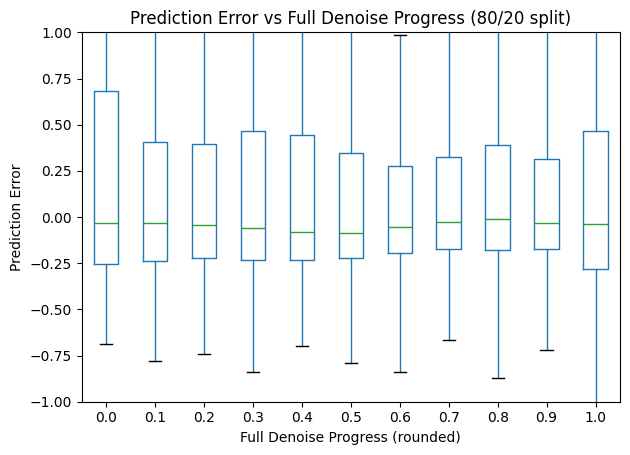

In [ ]:
plot_error_vs_progress(plot_df, title_suffix=title_suffix)

### plot_steps_left

#### function

In [ ]:
def plot_steps_left(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(plot_df["num_unmasked_tokens"], plot_df["y_test_steps"], alpha=0.3, label="Actual")
    plt.scatter(plot_df["num_unmasked_tokens"], plot_df["y_pred_steps"], alpha=0.3, label="Predicted")
    plt.xlabel("Num Unmasked Tokens")
    plt.ylabel("Num Denoise Steps Left")
    plt.title(f"Predicted vs Actual Denoise Steps Left{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("denoise_steps_prediction.png", dpi=300)

#### run

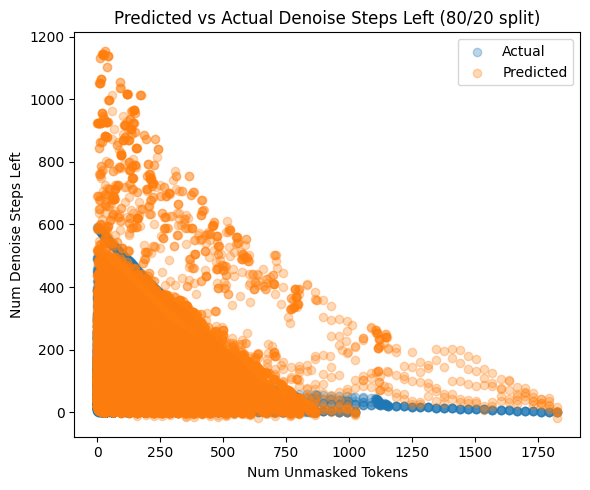

In [ ]:
plot_steps_left(plot_df, title_suffix=title_suffix)

### plot_ratio_prediction

#### function

In [ ]:
def plot_ratio_prediction(plot_df: pd.DataFrame, y_test: pd.Series, y_pred: np.ndarray, title_suffix: str = "") -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.xlabel("Actual Denoise Ratio")
    plt.ylabel("Predicted Denoise Ratio")
    for threshold in plot_df["confidence_threshold"].unique():
        subset = plot_df[plot_df["confidence_threshold"] == threshold]
        plt.scatter(subset["y_test_ratio"], subset["y_pred_ratio"], alpha=0.3, label=f"Threshold {threshold}")
    plt.legend(title="Confidence Threshold")
    plt.title(f"Predicted vs Actual Denoise Ratio{title_suffix}")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.tight_layout()
    plt.savefig("denoise_ratio_prediction.png", dpi=300)

#### run

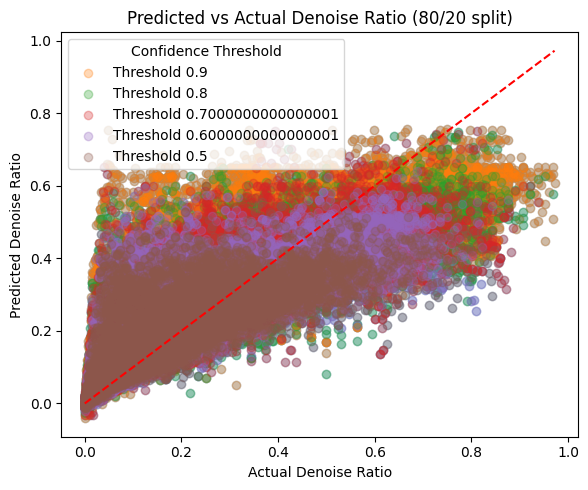

In [ ]:
plot_ratio_prediction(plot_df, y_test, y_pred, title_suffix=title_suffix)

### plot_output_confidence

#### function

In [ ]:
def plot_output_confidence(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(plot_df["output_avg_confidence"], plot_df["y_test_ratio"], alpha=0.3)
    plt.xlabel("Output Average Confidence")
    plt.ylabel("Actual Denoise Ratio")
    plt.title(f"Output Average Confidence vs Actual Denoise Ratio{title_suffix}")
    plt.tight_layout()
    plt.savefig("output_avg_confidence_vs_denoise_ratio.png", dpi=300)

#### run

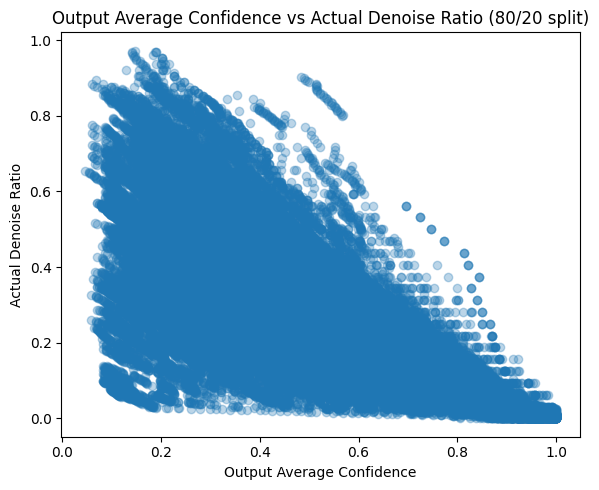

In [ ]:
plot_output_confidence(plot_df, title_suffix=title_suffix)